# 🌤️ Proof of Concept: Data Ingestion Cuaca Open-Meteo API

**Proyek:** Sistem Otomatis Deteksi Anomali Data Cuaca Open-Meteo untuk Smart Farming Berbasis MLOps

| | |
|---|---|
| **Nama** | Muhammad Ghazy Humaidi |
| **NIM** | 245150200111071 |
| **Mata Kuliah** | MLOps - TIF-B 2026 |
| **Dosen** | Rizal Setya Perdana, S.Kom., M.Kom., Ph.D. |

---

## 📋 Deskripsi Notebook

Notebook ini merupakan **Proof of Concept (PoC)** yang membuktikan bahwa:
1. Data cuaca dapat diambil secara otomatis dari **Open-Meteo API**
2. Data bersifat **Tabular Time-Series** yang cocok untuk klasifikasi anomali
3. Rule-based anomaly detection dapat mengklasifikasikan data ke **3 kelas** (Normal, Hardware Fault, Extreme Weather)
4. Data dapat disimpan untuk proses training model selanjutnya

## 1. 📦 Setup & Dependencies

Install dan import library yang dibutuhkan.

In [1]:
# Install dependencies (jika belum ada)
# !pip install requests pandas matplotlib scikit-learn

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Konfigurasi display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"Notebook dijalankan pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Notebook dijalankan pada: 2026-09-21 16:42:56
Pandas version: 2.2.3
NumPy version: 2.4.4


## 2. 🌐 Data Source: Open-Meteo API

Proyek ini menggunakan **[Open-Meteo API](https://open-meteo.com/)** sebagai sumber data tunggal.

**Kenapa Open-Meteo?**
- ✅ Gratis (Open-Access, tanpa API key)
- ✅ Data agrikultur lengkap (suhu, kelembaban, curah hujan, kelembaban tanah)
- ✅ Update setiap jam (cocok untuk micro-batch fetching)
- ✅ Mendukung data historis dan forecast

**Lokasi:** Malang, Jawa Timur (Lat: -7.95, Lon: 112.61)

## 3. 📥 Data Ingestion

Fungsi untuk mengambil data cuaca dari Open-Meteo API dengan variabel meteorologi yang relevan untuk Smart Agriculture.

In [3]:
def fetch_weather_data(past_days=7, forecast_days=1):
    """
    Mengambil data cuaca dari Open-Meteo API untuk area Malang.
    
    Parameters:
        past_days (int): Jumlah hari ke belakang untuk data historis
        forecast_days (int): Jumlah hari ke depan untuk forecast
    
    Returns:
        pd.DataFrame: Data cuaca per jam
    """
    print("Memulai proses Ingestion Data dari Open-Meteo API...")
    
    # Konfigurasi endpoint dan parameter
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": -7.95,
        "longitude": 112.61,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "soil_moisture_0_to_7cm",
            "shortwave_radiation",
            "wind_speed_10m"
        ],
        "timezone": "Asia/Jakarta",
        "past_days": past_days,
        "forecast_days": forecast_days,
    }
    
    # Hit API
    response = requests.get(url, params=params, timeout=30)
    
    if response.status_code == 200:
        data = response.json()
        print(f"✅ Data berhasil di-fetch (Status: {response.status_code})")
        
        # Ekstrak JSON ke DataFrame
        df = pd.DataFrame({
            "timestamp": data["hourly"]["time"],
            "temperature_2m_C": data["hourly"]["temperature_2m"],
            "humidity_percent": data["hourly"]["relative_humidity_2m"],
            "precipitation_mm": data["hourly"]["precipitation"],
            "soil_moisture": data["hourly"]["soil_moisture_0_to_7cm"],
            "radiation_wm2": data["hourly"]["shortwave_radiation"],
            "wind_speed_kmh": data["hourly"]["wind_speed_10m"],
        })
        
        # Convert timestamp
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        
        # Metadata
        print(f"📍 Lokasi: Lat {data['latitude']}, Lon {data['longitude']}")
        print(f"🕐 Timezone: {data['timezone']}")
        print(f"📊 Total data points: {len(df)} baris (update per jam)")
        print(f"📅 Range: {df['timestamp'].min()} → {df['timestamp'].max()}")
        
        return df
    else:
        print(f"❌ Gagal mengambil data. Status code: {response.status_code}")
        return None

# Eksekusi: ambil data 7 hari terakhir + 1 hari forecast
df_cuaca = fetch_weather_data(past_days=7, forecast_days=1)

Memulai proses Ingestion Data dari Open-Meteo API...


✅ Data berhasil di-fetch (Status: 200)
📍 Lokasi: Lat -7.9789104, Lon 112.59608
🕐 Timezone: Asia/Jakarta
📊 Total data points: 192 baris (update per jam)
📅 Range: 2026-09-14 00:00:00 → 2026-09-21 23:00:00


## 4. 🔍 Exploratory Data Analysis (EDA)

Eksplorasi data untuk memahami karakteristik dan distribusi variabel cuaca.

### 4.1 Snapshot Data

In [4]:
if df_cuaca is not None:
    print("=" * 60)
    print("📋 5 BARIS PERTAMA (SNAPSHOT DATA)")
    print("=" * 60)
    display(df_cuaca.head())
    
    print("\n" + "=" * 60)
    print("📋 5 BARIS TERAKHIR")
    print("=" * 60)
    display(df_cuaca.tail())

📋 5 BARIS PERTAMA (SNAPSHOT DATA)


,timestamp,temperature_2m_C,humidity_percent,precipitation_mm,soil_moisture,radiation_wm2,wind_speed_kmh
0,2026-09-14 00:00:00,19.8,77,0.0,0.145,0.0,3.3
1,2026-09-14 01:00:00,19.5,78,0.0,0.151,0.0,2.7
2,2026-09-14 02:00:00,19.3,78,0.0,0.150,0.0,3.3
3,2026-09-14 03:00:00,19.3,80,0.0,0.150,0.0,3.8
4,2026-09-14 04:00:00,18.9,83,0.0,0.150,0.0,5.4



📋 5 BARIS TERAKHIR


,timestamp,temperature_2m_C,humidity_percent,precipitation_mm,soil_moisture,radiation_wm2,wind_speed_kmh
187,2026-09-21 19:00:00,22.6,73,0.0,0.153,0.0,3.3
188,2026-09-21 20:00:00,21.8,78,0.0,0.152,0.0,4.5
189,2026-09-21 21:00:00,21.2,81,0.0,0.152,0.0,3.6
190,2026-09-21 22:00:00,20.6,85,0.0,0.152,0.0,4.2
191,2026-09-21 23:00:00,20.1,87,0.0,0.152,0.0,4.3


### 4.2 Informasi Struktur Data

In [5]:
if df_cuaca is not None:
    print("=" * 60)
    print("📊 INFO STRUKTUR DATA")
    print("=" * 60)
    print(f"Shape: {df_cuaca.shape}")
    print(f"Columns: {list(df_cuaca.columns)}")
    print()
    df_cuaca.info()
    
    print("\n" + "=" * 60)
    print("📊 MISSING VALUES")
    print("=" * 60)
    missing = df_cuaca.isnull().sum()
    print(missing)
    print(f"\nTotal missing values: {missing.sum()}")

📊 INFO STRUKTUR DATA
Shape: (192, 7)
Columns: ['timestamp', 'temperature_2m_C', 'humidity_percent', 'precipitation_mm', 'soil_moisture', 'radiation_wm2', 'wind_speed_kmh']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         192 non-null    datetime64[ns]
 1   temperature_2m_C  192 non-null    float64       
 2   humidity_percent  192 non-null    int64         
 3   precipitation_mm  192 non-null    float64       
 4   soil_moisture     192 non-null    float64       
 5   radiation_wm2     192 non-null    float64       
 6   wind_speed_kmh    192 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 10.6 KB

📊 MISSING VALUES
timestamp           0
temperature_2m_C    0
humidity_percent    0
precipitation_mm    0
soil_moisture       0
radiation_wm2       0
wind_speed_kmh   

### 4.3 Statistik Deskriptif

In [6]:
if df_cuaca is not None:
    print("=" * 60)
    print("📊 STATISTIK DESKRIPTIF")
    print("=" * 60)
    display(df_cuaca.describe())

📊 STATISTIK DESKRIPTIF


,timestamp,temperature_2m_C,humidity_percent,precipitation_mm,soil_moisture,radiation_wm2,wind_speed_kmh
count,192,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,2026-09-17 23:30:00,23.510417,72.052083,0.057813,0.160781,287.750000,5.000521
min,2026-09-14 00:00:00,17.600000,24.000000,0.000000,0.134000,0.000000,0.200000
25%,2026-09-15 23:45:00,19.975000,51.750000,0.000000,0.149750,0.000000,2.700000
50%,2026-09-17 23:30:00,22.350000,78.500000,0.000000,0.155000,13.000000,4.200000
75%,2026-09-19 23:15:00,27.200000,90.000000,0.000000,0.174000,618.500000,7.600000
max,2026-09-21 23:00:00,31.400000,100.000000,2.700000,0.199000,1037.000000,12.100000
std,NaN,3.913046,20.329933,0.264954,0.017387,368.066435,2.810498


## 5. 📈 Visualisasi Data Cuaca

Visualisasi time-series untuk setiap variabel meteorologi.

C:\Users\HP\AppData\Local\Temp\ipykernel_39340\3695319264.py:40: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_39340\3695319264.py:40: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_39340\3695319264.py:40: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_39340\3695319264.py:40: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_39340\3695319264.py:40: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_39340\3695319264.py:40: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\HP\AppData\Local\Temp\ipykernel_39340\3695319264.py:40: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()


C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


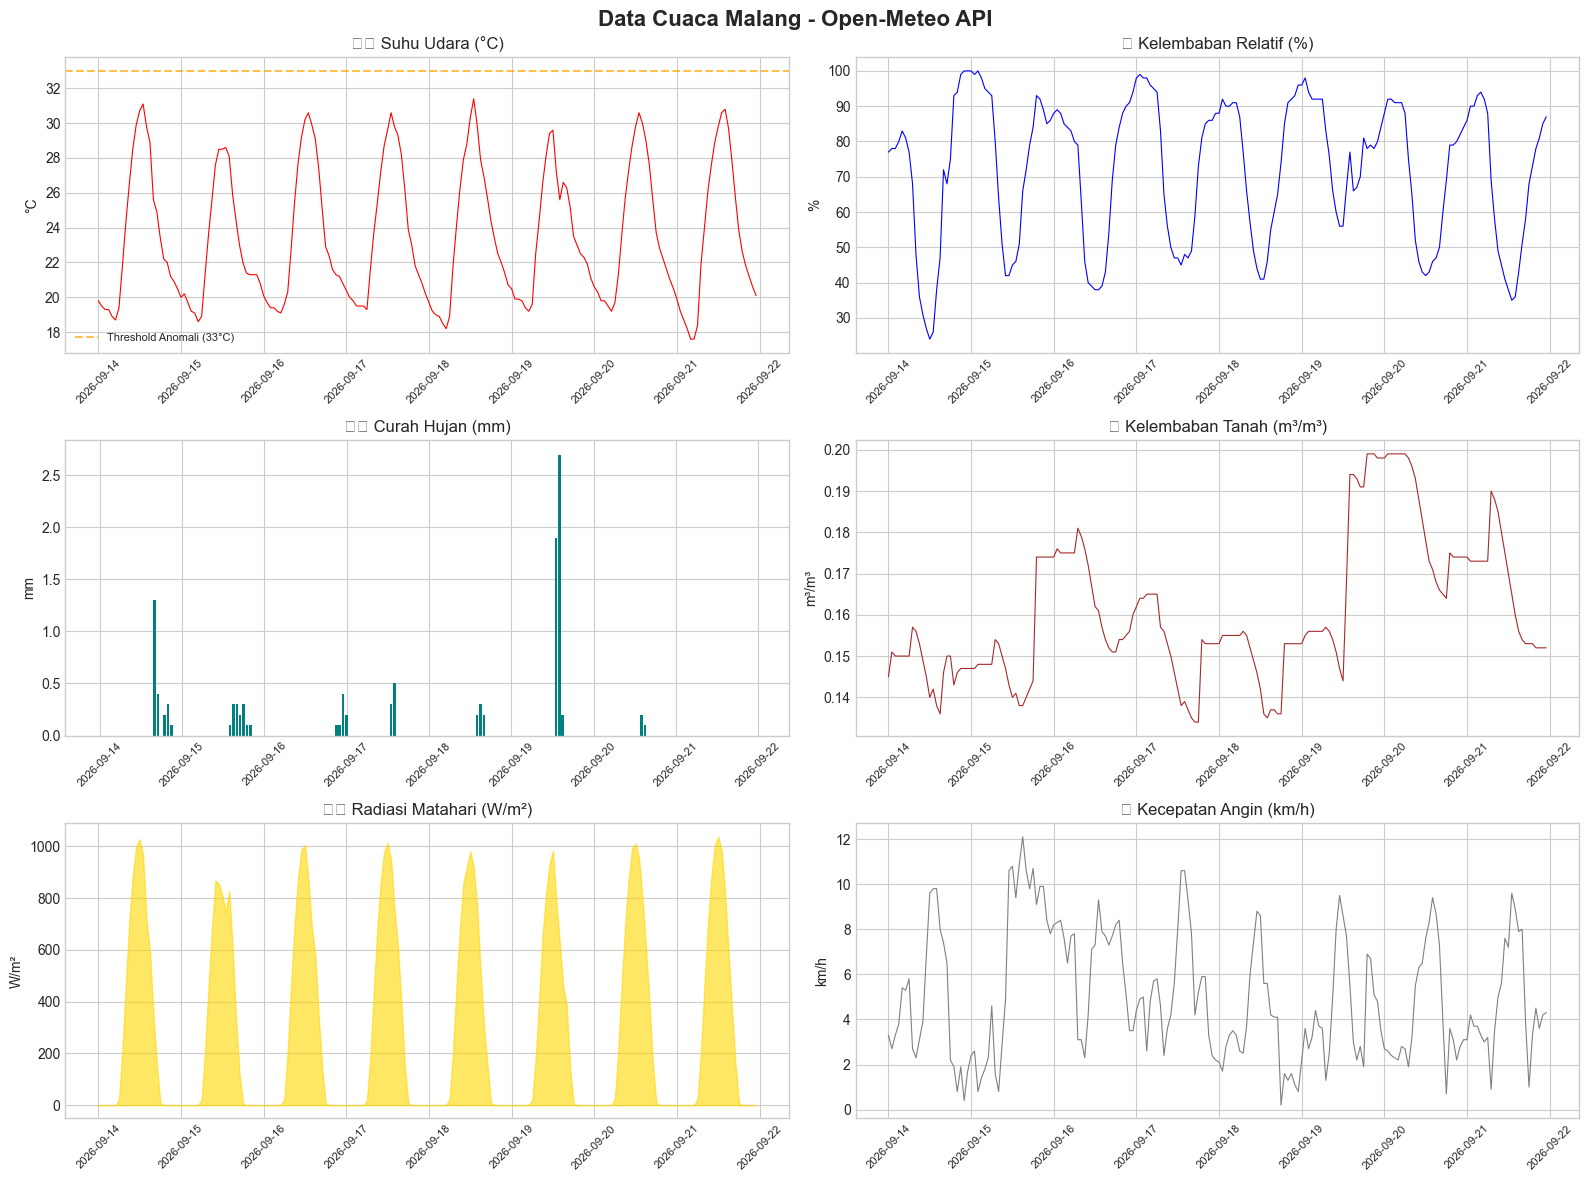

In [7]:
if df_cuaca is not None:
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle('Data Cuaca Malang - Open-Meteo API', fontsize=16, fontweight='bold')
    
    # Temperature
    axes[0, 0].plot(df_cuaca['timestamp'], df_cuaca['temperature_2m_C'], color='red', linewidth=0.8)
    axes[0, 0].set_title('🌡️ Suhu Udara (°C)')
    axes[0, 0].set_ylabel('°C')
    axes[0, 0].axhline(y=33, color='orange', linestyle='--', alpha=0.7, label='Threshold Anomali (33°C)')
    axes[0, 0].legend(fontsize=8)
    
    # Humidity
    axes[0, 1].plot(df_cuaca['timestamp'], df_cuaca['humidity_percent'], color='blue', linewidth=0.8)
    axes[0, 1].set_title('💧 Kelembaban Relatif (%)')
    axes[0, 1].set_ylabel('%')
    
    # Precipitation
    axes[1, 0].bar(df_cuaca['timestamp'], df_cuaca['precipitation_mm'], color='teal', width=0.03)
    axes[1, 0].set_title('🌧️ Curah Hujan (mm)')
    axes[1, 0].set_ylabel('mm')
    
    # Soil Moisture
    axes[1, 1].plot(df_cuaca['timestamp'], df_cuaca['soil_moisture'], color='brown', linewidth=0.8)
    axes[1, 1].set_title('🌱 Kelembaban Tanah (m³/m³)')
    axes[1, 1].set_ylabel('m³/m³')
    
    # Radiation
    axes[2, 0].fill_between(df_cuaca['timestamp'], df_cuaca['radiation_wm2'], color='gold', alpha=0.6)
    axes[2, 0].set_title('☀️ Radiasi Matahari (W/m²)')
    axes[2, 0].set_ylabel('W/m²')
    
    # Wind Speed
    axes[2, 1].plot(df_cuaca['timestamp'], df_cuaca['wind_speed_kmh'], color='gray', linewidth=0.8)
    axes[2, 1].set_title('💨 Kecepatan Angin (km/h)')
    axes[2, 1].set_ylabel('km/h')
    
    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    plt.tight_layout()
    plt.show()

### 5.1 Heatmap Korelasi Antar Variabel

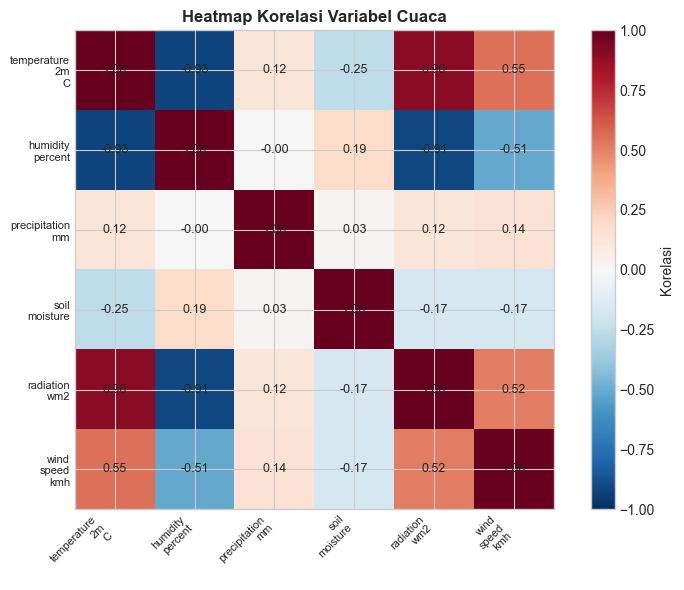

In [8]:
if df_cuaca is not None:
    numeric_cols = ['temperature_2m_C', 'humidity_percent', 'precipitation_mm', 
                    'soil_moisture', 'radiation_wm2', 'wind_speed_kmh']
    corr_matrix = df_cuaca[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels([c.replace('_', '\n') for c in numeric_cols], fontsize=8, rotation=45, ha='right')
    ax.set_yticklabels([c.replace('_', '\n') for c in numeric_cols], fontsize=8)
    
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
    
    plt.colorbar(im, ax=ax, label='Korelasi')
    plt.title('Heatmap Korelasi Variabel Cuaca', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. 🚨 Rule-Based Anomaly Detection (3 Class Taxonomy)

Implementasi deteksi anomali menggunakan **rule-based labeling engine** berdasarkan **Taksonomi Kegagalan Sensor IoT** dan **Ambang Batas Agrometeorologi Kota Malang** yang dirancang pada dokumen perancangan LK-03:

### 📋 Ringkasan Taksonomi & Batasan Multikelas:
| Class | Kategori | Modus / Kondisi | Ambang Batas Logis |
|---|---|---|---|
| **0** | **Normal State** | Kondisi Operasional Wajar | Suhu 18.0–32.0°C, RH 55–95%, Hujan 0–15 mm/jam, Soil Moisture 0.18–0.40 $m^3/m^3$, Radiasi 0–950 $W/m^2$, Angin 2–25 km/h |
| **1** | **Hardware Fault / Ingestion Error** | **1. Out-of-Bounds (OOB)**<br>**2. Missing Data**<br>**3. Night Radiation Glitch**<br>**4. Cross-Feature Discordance**<br>**5. Gradient Spiking**<br>**6. Stuck Value (Zero Variance)** | • $T < -20^\circ\text{C}$ atau $> 55^\circ\text{C}$, RH $< 0\%$ atau $> 100\%$, Rain $< 0$, Soil $< 0$ atau $> 0.55$, Rad $< 0$, Wind $< 0$<br>• Terdapat nilai `NULL` / `NaN` pada metrik utama<br>• Radiasi $> 0\text{ W/m}^2$ pada jam malam (20.00 – 04.00 WIB)<br>• Hujan lebat ($>15\text{ mm}$) saat radiasi $>800\text{ W/m}^2$, atau lonjakan soil $>0.30$ tanpa hujan<br>• $|\Delta T| > 8.0^\circ\text{C}/\text{jam}$ tanpa presipitasi<br>• Suhu konstan 12 jam ($\sigma_{12\text{h}}=0$), RH jenuh 100% 24 jam, atau angin 0 km/h 48 jam |
| **2** | **Extreme Environmental Anomaly** | **1. Extreme Heat (Heatwave)**<br>**2. Extreme Cold (Frost)**<br>**3. Severe Dry Air (VPD Spike)**<br>**4. Torrential Rainfall (Badai)**<br>**5. Critical Drought (Wilting)**<br>**6. Severe Flood / Waterlogging**<br>**7. Extreme Solar Radiation**<br>**8. High Gale Wind (Badai Angin)** | • Suhu udara $> 33.5^\circ\text{C}$ ($> P_{99}$ baseline)<br>• Suhu udara $< 15.0^\circ\text{C}$ ($< P_1$ baseline)<br>• Kelembaban udara $< 40.0\%$ (Shock transpirasi tanaman)<br>• Curah hujan $> 25.0\text{ mm/jam}$ (Standar BMKG hujan sangat lebat)<br>• Kelembaban tanah $< 0.08\text{ m}^3/\text{m}^3$ (*Permanent Wilting Point*)<br>• Kelembaban tanah $> 0.48\text{ m}^3/\text{m}^3$ (Kondisi anoksia perakaran)<br>• Radiasi matahari $> 1100.0\text{ W/m}^2$ (Risiko *sunscald* buah)<br>• Kecepatan angin $> 40.0\text{ km/h}$ (*Strong Breeze* skala Beaufort) |

> **Hierarki Prioritas Evaluasi**:
> 1. **Class 1 (Hardware Fault)** dievaluasi pertama: Jika data cacat secara fisik atau transmisi putus, klasifikasi cuaca tidak valid.
> 2. **Class 2 (Extreme Environmental Anomaly)** dievaluasi kedua: Kondisi lingkungan aktual berbahaya yang memerlukan intervensi aktuator cerdas.
> 3. **Class 0 (Normal State)**: Jika lolos dari Class 1 dan Class 2, maka data berada dalam batas kesetimbangan operasional normal.


In [9]:
def prepare_temporal_indicators(df):
    """
    Menghitung indikator temporal & rolling window untuk mendeteksi
    anomali berbasis sekuens deret waktu (stuck values, gradient spike, waterlogging).
    """
    df_temp = df.copy()
    
    # 1. Delta perubahan suhu 1 jam
    df_temp['temp_diff_1h'] = df_temp['temperature_2m_C'].diff().abs()
    
    # 2. Standar deviasi suhu 12 jam (stuck value jika std == 0)
    df_temp['temp_std_12h'] = df_temp['temperature_2m_C'].rolling(12, min_periods=12).std()
    
    # 3. Kelembaban jenuh 100% konstan selama 24 jam berturut-turut
    df_temp['humidity_stuck_100_24h'] = (df_temp['humidity_percent'] >= 100.0).rolling(24, min_periods=24).min() == 1
    
    # 4. Kecepatan angin 0.0 km/h macet selama 48 jam berturut-turut
    df_temp['wind_zero_48h'] = (df_temp['wind_speed_kmh'] <= 0.0).rolling(48, min_periods=48).min() == 1
    
    # 5. Delta kelembaban tanah 1 jam
    df_temp['soil_diff_1h'] = df_temp['soil_moisture'].diff()
    
    # 6. Waterlogging: kelembaban tanah > 0.48 m3/m3 selama > 48 jam berturut-turut
    df_temp['soil_waterlogged_48h'] = (df_temp['soil_moisture'] > 0.48).rolling(48, min_periods=48).min() == 1
    
    return df_temp


def classify_anomaly(row):
    """
    Mengklasifikasikan setiap baris data cuaca ke dalam 3 kelas anomali berdasarkan
    Taksonomi Kegagalan Sensor dan Ambang Batas Agrometeorologi Wilayah Kota Malang (LK-03).
    
    Returns:
        tuple: (anomaly_class: int, anomaly_reason: str)
    """
    # =========================================================================
    # CLASS 1: HARDWARE FAULT & DATA INGESTION ERROR (Prioritas 1)
    # =========================================================================
    
    # 1.1 Null / Missing Data (Packet Loss / API Timeout)
    required_cols = ['temperature_2m_C', 'humidity_percent', 'precipitation_mm', 
                     'soil_moisture', 'radiation_wm2', 'wind_speed_kmh']
    for col in required_cols:
        if pd.isna(row.get(col)):
            return 1, f"Hardware Fault: Missing / NaN in '{col}' (Packet Loss)"

    temp = row['temperature_2m_C']
    hum = row['humidity_percent']
    precip = row['precipitation_mm']
    soil = row['soil_moisture']
    rad = row['radiation_wm2']
    wind = row['wind_speed_kmh']
    
    # 1.2 Out-of-Bounds (OOB) Sensor Failure
    if temp < -20.0 or temp > 55.0:
        return 1, f"Hardware Fault: Temperature OOB ({temp:.1f}°C, range: -20 s.d. 55°C)"
    if hum < 0.0 or hum > 100.0:
        return 1, f"Hardware Fault: Humidity OOB ({hum:.1f}%, range: 0 s.d. 100%)"
    if precip < 0.0:
        return 1, f"Hardware Fault: Negative precipitation ({precip:.2f} mm)"
    if soil < 0.00 or soil > 0.55:
        return 1, f"Hardware Fault: Soil moisture OOB ({soil:.3f} m³/m³, range: 0.0 s.d. 0.55)"
    if rad < 0.0:
        return 1, f"Hardware Fault: Negative radiation ({rad:.1f} W/m²)"
    if wind < 0.0:
        return 1, f"Hardware Fault: Negative wind speed ({wind:.1f} km/h)"
        
    # 1.3 Night Radiation Glitch (Kebocoran fotodioda pada 20.00 - 04.00 WIB)
    hour = row['timestamp'].hour if hasattr(row['timestamp'], 'hour') else pd.to_datetime(row['timestamp']).hour
    if (hour >= 20 or hour < 4) and rad > 0.0:
        return 1, f"Hardware Fault: Night radiation glitch ({rad:.1f} W/m² at {hour:02d}:00 WIB)"

    # 1.4 Cross-Feature Discordance (Kontradiksi kausalitas fisik sensor)
    if precip > 15.0 and rad > 800.0:
        return 1, f"Hardware Fault: Discordance (Heavy rain {precip:.1f} mm with extreme radiation {rad:.1f} W/m²)"
        
    soil_diff = row.get('soil_diff_1h')
    if soil_diff is not None and not pd.isna(soil_diff):
        if soil_diff > 0.30 and precip == 0.0 and rad > 800.0:
            return 1, f"Hardware Fault: Soil moisture surge (+{soil_diff:.2f}) under hot sun without rain"
        if precip > 20.0 and abs(soil_diff) < 0.0001:
            return 1, f"Hardware Fault: Soil probe unresponsive (Δsoil=0.0 during rain {precip:.1f} mm)"

    # 1.5 Gradient Spiking (Transient Jump tanpa presipitasi)
    temp_diff = row.get('temp_diff_1h')
    if temp_diff is not None and not pd.isna(temp_diff):
        if temp_diff > 8.0 and precip == 0.0:
            return 1, f"Hardware Fault: Temperature spike (|ΔT|={temp_diff:.1f}°C/hr without rain)"

    # 1.6 Stuck Value (Zero Variance / Sensor Macet)
    temp_std = row.get('temp_std_12h')
    if temp_std is not None and not pd.isna(temp_std) and temp_std == 0.0:
        return 1, "Hardware Fault: Temperature sensor stuck (constant value for 12 hours)"
    if row.get('humidity_stuck_100_24h') is True:
        return 1, "Hardware Fault: Humidity saturated 100% stuck for >24 hours"
    if row.get('wind_zero_48h') is True:
        return 1, "Hardware Fault: Anemometer stuck at 0.0 km/h for >48 hours"

    # =========================================================================
    # CLASS 2: EXTREME ENVIRONMENTAL ANOMALY (Prioritas 2)
    # =========================================================================
    
    # 2.1 Suhu Panas Ekstrem (> 33.5°C) -> Heat Stress Tanaman
    if temp > 33.5:
        return 2, f"Extreme Weather: Heatwave / Heat Stress ({temp:.1f}°C > 33.5°C)"
    
    # 2.2 Suhu Dingin Ekstrem (< 15.0°C) -> Frost Risk / Embun Upas
    if temp < 15.0:
        return 2, f"Extreme Weather: Severe Cold / Frost Risk ({temp:.1f}°C < 15.0°C)"
    
    # 2.3 Udara Kering Ekstrem (< 40.0%) -> Acute Transpiration Shock (VPD spike)
    if hum < 40.0:
        return 2, f"Extreme Weather: Severe Dry Air ({hum:.1f}% < 40.0%)"
    
    # 2.4 Badai Hujan Tropis Ekstrem (> 25.0 mm/jam) -> Erosi & Flash Flood
    if precip > 25.0:
        return 2, f"Extreme Weather: Torrential Rainfall ({precip:.1f} mm/hr > 25.0 mm/hr)"
    
    # 2.5 Kekeringan Kritis / Titik Layu Permanen (< 0.08 m³/m³)
    if soil < 0.08:
        return 2, f"Extreme Weather: Critical Drought / Wilting Point ({soil:.3f} m³/m³ < 0.08)"
    
    # 2.6 Kejenuhan Berlebih / Waterlogging (> 0.48 m³/m³)
    if row.get('soil_waterlogged_48h') is True or soil > 0.48:
        return 2, f"Extreme Weather: Waterlogging / Root Anoxia ({soil:.3f} m³/m³ > 0.48)"
    
    # 2.7 Radiasi Matahari Ekstrem (> 1100.0 W/m²) -> Sunscald & Klorosis
    if rad > 1100.0:
        return 2, f"Extreme Weather: Extreme Solar Radiation ({rad:.1f} W/m² > 1100 W/m²)"
    
    # 2.8 Angin Kencang / Badai (> 40.0 km/h) -> Strong Breeze / Kerusakan Fisik
    if wind > 40.0:
        return 2, f"Extreme Weather: High Gale Wind ({wind:.1f} km/h > 40.0 km/h)"

    # =========================================================================
    # CLASS 0: NORMAL STATE (Default)
    # =========================================================================
    return 0, "Normal State"


# Eksekusi Klasifikasi pada Dataset Hasil Ingestion
if df_cuaca is not None:
    # 1. Siapkan fitur temporal deret waktu
    df_cuaca_prepared = prepare_temporal_indicators(df_cuaca)
    
    # 2. Aplikasikan fungsi klasifikasi berbasis aturan
    classification_results = df_cuaca_prepared.apply(classify_anomaly, axis=1)
    df_cuaca['anomaly_class'] = classification_results.apply(lambda x: x[0])
    df_cuaca['anomaly_reason'] = classification_results.apply(lambda x: x[1])
    
    # 3. Tampilkan ringkasan distribusi kelas
    print("=" * 65)
    print("🚨 HASIL RULE-BASED ANOMALY DETECTION (LK-03 FRAMEWORK)")
    print("=" * 65)
    
    class_labels = {
        0: 'Class 0: Normal State',
        1: 'Class 1: Hardware Fault',
        2: 'Class 2: Extreme Environmental'
    }
    
    class_counts = df_cuaca['anomaly_class'].value_counts().reindex([0, 1, 2], fill_value=0)
    for cls in [0, 1, 2]:
        count = class_counts[cls]
        pct = count / len(df_cuaca) * 100 if len(df_cuaca) > 0 else 0
        print(f"  {class_labels[cls]}: {count:3d} baris ({pct:5.1f}%)")
    
    print(f"\nTotal Data Dievaluasi: {len(df_cuaca)} baris deret waktu")
    
    # 4. Tampilkan sampel anomali terdeteksi
    anomalies = df_cuaca[df_cuaca['anomaly_class'] != 0]
    if not anomalies.empty:
        print(f"\n⚠️ Ditemukan {len(anomalies)} observasi anomali pada data riil:")
        display(anomalies[['timestamp', 'temperature_2m_C', 'humidity_percent', 
                           'precipitation_mm', 'soil_moisture', 'radiation_wm2', 
                           'wind_speed_kmh', 'anomaly_class', 'anomaly_reason']].head(10))
    else:
        print("\n✅ Semua data observasi riil berada dalam kondisi normal (Class 0).")


🚨 HASIL RULE-BASED ANOMALY DETECTION (LK-03 FRAMEWORK)
  Class 0: Normal State: 179 baris ( 93.2%)
  Class 1: Hardware Fault:   0 baris (  0.0%)
  Class 2: Extreme Environmental:  13 baris (  6.8%)

Total Data Dievaluasi: 192 baris deret waktu

⚠️ Ditemukan 13 observasi anomali pada data riil:


,timestamp,temperature_2m_C,humidity_percent,precipitation_mm,soil_moisture,radiation_wm2,wind_speed_kmh,anomaly_class,anomaly_reason
9,2026-09-14 09:00:00,26.5,36,0.0,0.153,706.0,3.1,2,Extreme Weather: Severe Dry Air (36.0% < 40.0%)
10,2026-09-14 10:00:00,28.5,31,0.0,0.149,887.0,3.9,2,Extreme Weather: Severe Dry Air (31.0% < 40.0%)
11,2026-09-14 11:00:00,29.9,27,0.0,0.145,1000.0,6.8,2,Extreme Weather: Severe Dry Air (27.0% < 40.0%)
12,2026-09-14 12:00:00,30.7,24,0.0,0.140,1027.0,9.6,2,Extreme Weather: Severe Dry Air (24.0% < 40.0%)
13,2026-09-14 13:00:00,31.1,26,0.0,0.142,966.0,9.8,2,Extreme Weather: Severe Dry Air (26.0% < 40.0%)
14,2026-09-14 14:00:00,29.8,38,0.0,0.138,716.0,9.8,2,Extreme Weather: Severe Dry Air (38.0% < 40.0%)
59,2026-09-16 11:00:00,29.2,39,0.0,0.167,987.0,7.1,2,Extreme Weather: Severe Dry Air (39.0% < 40.0%)
60,2026-09-16 12:00:00,30.2,38,0.0,0.162,1006.0,7.3,2,Extreme Weather: Severe Dry Air (38.0% < 40.0%)
61,2026-09-16 13:00:00,30.6,38,0.0,0.161,870.0,9.3,2,Extreme Weather: Severe Dry Air (38.0% < 40.0%)
62,2026-09-16 14:00:00,29.9,39,0.0,0.157,687.0,7.9,2,Extreme Weather: Severe Dry Air (39.0% < 40.0%)


### 6.1 Pengujian Skenario & Injeksi Anomali (Quality Gate Validation)

Karena data Open-Meteo API berbasis simulasi numerik atmosferik bersih (tidak mengalami kerusakan fisik sensor IoT di lapangan secara natural), modul di bawah ini melakukan **uji injeksi sinyal cacat (*synthetic fault injection*)** untuk membuktikan bahwa engine klasifikasi mampu mendeteksi seluruh modus kegagalan **Class 1 (Hardware Fault)** dan kondisi **Class 2 (Extreme Weather)** secara presisi:


In [10]:
# Uji Injeksi Skenario Sintetis untuk Memverifikasi Taksonomi Anomali
test_scenarios = [
    {"deskripsi": "Baseline Normal Siang Hari", "timestamp": pd.Timestamp("2026-09-20 12:00:00"), "temperature_2m_C": 27.5, "humidity_percent": 68.0, "precipitation_mm": 0.0, "soil_moisture": 0.28, "radiation_wm2": 650.0, "wind_speed_kmh": 11.0},
    {"deskripsi": "Hardware: Suhu Out-of-Bounds (>55°C)", "timestamp": pd.Timestamp("2026-09-20 13:00:00"), "temperature_2m_C": 64.0, "humidity_percent": 70.0, "precipitation_mm": 0.0, "soil_moisture": 0.25, "radiation_wm2": 700.0, "wind_speed_kmh": 8.0},
    {"deskripsi": "Hardware: Sensor Null / Missing Data", "timestamp": pd.Timestamp("2026-09-20 14:00:00"), "temperature_2m_C": np.nan, "humidity_percent": 70.0, "precipitation_mm": 0.0, "soil_moisture": 0.25, "radiation_wm2": 700.0, "wind_speed_kmh": 8.0},
    {"deskripsi": "Hardware: Night Radiation Glitch (Malam Hari)", "timestamp": pd.Timestamp("2026-09-20 23:00:00"), "temperature_2m_C": 21.5, "humidity_percent": 88.0, "precipitation_mm": 0.0, "soil_moisture": 0.30, "radiation_wm2": 180.0, "wind_speed_kmh": 4.0},
    {"deskripsi": "Hardware: Cross-Feature Discordance", "timestamp": pd.Timestamp("2026-09-20 12:00:00"), "temperature_2m_C": 31.0, "humidity_percent": 75.0, "precipitation_mm": 24.0, "soil_moisture": 0.32, "radiation_wm2": 950.0, "wind_speed_kmh": 6.0},
    {"deskripsi": "Hardware: Transient Spiking (>8°C/jam)", "timestamp": pd.Timestamp("2026-09-20 15:00:00"), "temperature_2m_C": 34.0, "humidity_percent": 55.0, "precipitation_mm": 0.0, "soil_moisture": 0.25, "radiation_wm2": 600.0, "wind_speed_kmh": 7.0, "temp_diff_1h": 9.8},
    {"deskripsi": "Hardware: Temperature Stuck (Zero Variance)", "timestamp": pd.Timestamp("2026-09-20 16:00:00"), "temperature_2m_C": 25.0, "humidity_percent": 65.0, "precipitation_mm": 0.0, "soil_moisture": 0.25, "radiation_wm2": 450.0, "wind_speed_kmh": 5.0, "temp_std_12h": 0.0},
    {"deskripsi": "Ekstrem: Gelombang Panas (>33.5°C)", "timestamp": pd.Timestamp("2026-09-20 13:00:00"), "temperature_2m_C": 35.5, "humidity_percent": 42.0, "precipitation_mm": 0.0, "soil_moisture": 0.18, "radiation_wm2": 980.0, "wind_speed_kmh": 14.0},
    {"deskripsi": "Ekstrem: Udara Kering Kritis (<40%)", "timestamp": pd.Timestamp("2026-09-20 14:00:00"), "temperature_2m_C": 32.0, "humidity_percent": 32.0, "precipitation_mm": 0.0, "soil_moisture": 0.14, "radiation_wm2": 890.0, "wind_speed_kmh": 16.0},
    {"deskripsi": "Ekstrem: Badai Hujan Tropis (>25 mm/jam)", "timestamp": pd.Timestamp("2026-09-20 16:00:00"), "temperature_2m_C": 22.0, "humidity_percent": 96.0, "precipitation_mm": 42.0, "soil_moisture": 0.44, "radiation_wm2": 30.0, "wind_speed_kmh": 28.0},
    {"deskripsi": "Ekstrem: Kekeringan Kritis (Wilting Point)", "timestamp": pd.Timestamp("2026-09-20 11:00:00"), "temperature_2m_C": 31.0, "humidity_percent": 45.0, "precipitation_mm": 0.0, "soil_moisture": 0.055, "radiation_wm2": 850.0, "wind_speed_kmh": 12.0},
    {"deskripsi": "Ekstrem: Badai Angin Kencang (>40 km/h)", "timestamp": pd.Timestamp("2026-09-20 17:00:00"), "temperature_2m_C": 23.0, "humidity_percent": 85.0, "precipitation_mm": 10.0, "soil_moisture": 0.32, "radiation_wm2": 100.0, "wind_speed_kmh": 46.5}
]

df_sim = pd.DataFrame(test_scenarios)
res_sim = df_sim.apply(classify_anomaly, axis=1)
df_sim['predicted_class'] = res_sim.apply(lambda x: x[0])
df_sim['classification_reason'] = res_sim.apply(lambda x: x[1])

print("🧪 VALIDASI INJEKSI SKENARIO UJI (PEMBUKTIAN TAKSONOMI LK-03):")
display(df_sim[['deskripsi', 'predicted_class', 'classification_reason']])


🧪 VALIDASI INJEKSI SKENARIO UJI (PEMBUKTIAN TAKSONOMI LK-03):


,deskripsi,predicted_class,classification_reason
0,Baseline Normal Siang Hari,0,Normal State
1,Hardware: Suhu Out-of-Bounds (>55°C),1,"Hardware Fault: Temperature OOB (64.0°C, range..."
2,Hardware: Sensor Null / Missing Data,1,Hardware Fault: Missing / NaN in 'temperature_...
3,Hardware: Night Radiation Glitch (Malam Hari),1,Hardware Fault: Night radiation glitch (180.0 ...
4,Hardware: Cross-Feature Discordance,1,Hardware Fault: Discordance (Heavy rain 24.0 m...
5,Hardware: Transient Spiking (>8°C/jam),1,Hardware Fault: Temperature spike (|ΔT|=9.8°C/...
6,Hardware: Temperature Stuck (Zero Variance),1,Hardware Fault: Temperature sensor stuck (cons...
7,Ekstrem: Gelombang Panas (>33.5°C),2,Extreme Weather: Heatwave / Heat Stress (35.5°...
8,Ekstrem: Udara Kering Kritis (<40%),2,Extreme Weather: Severe Dry Air (32.0% < 40.0%)
9,Ekstrem: Badai Hujan Tropis (>25 mm/jam),2,Extreme Weather: Torrential Rainfall (42.0 mm/...


### 6.2 Visualisasi Distribusi Kelas Anomali


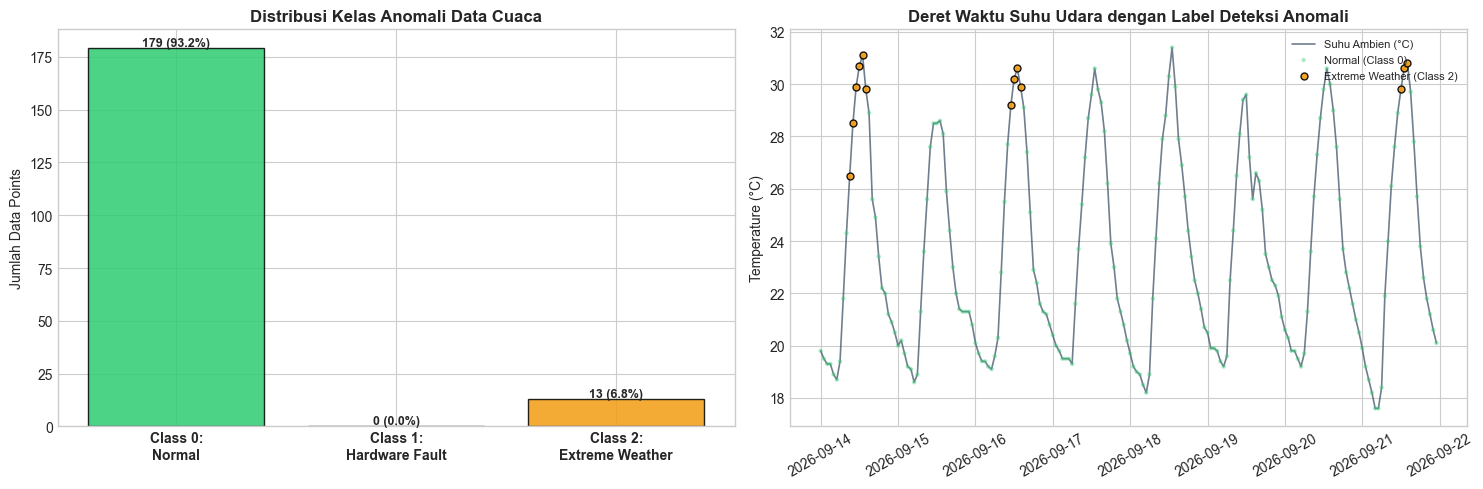

In [11]:
if df_cuaca is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Distribusi kelas
    class_counts = df_cuaca['anomaly_class'].value_counts().reindex([0, 1, 2], fill_value=0)
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    labels = ['Class 0:\nNormal', 'Class 1:\nHardware Fault', 'Class 2:\nExtreme Weather']
    bars = axes[0].bar([0, 1, 2], class_counts.values, color=colors, edgecolor='black', alpha=0.85)
    axes[0].set_xticks([0, 1, 2])
    axes[0].set_xticklabels(labels, fontsize=10, fontweight='bold')
    axes[0].set_title('Distribusi Kelas Anomali Data Cuaca', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Jumlah Data Points')
    
    for bar, val in zip(bars, class_counts.values):
        pct = (val / len(df_cuaca)) * 100 if len(df_cuaca) > 0 else 0
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0, 
                     f"{val} ({pct:.1f}%)", ha='center', fontweight='bold', fontsize=9)
    
    # Plot 2: Time-series Suhu dengan Anomali Markers
    axes[1].plot(df_cuaca['timestamp'], df_cuaca['temperature_2m_C'], 
                color='#34495e', linewidth=1.2, alpha=0.7, label='Suhu Ambien (°C)')
    
    color_map = {0: '#2ecc71', 1: '#e74c3c', 2: '#f39c12'}
    label_map = {0: 'Normal (Class 0)', 1: 'Hardware Fault (Class 1)', 2: 'Extreme Weather (Class 2)'}
    
    for cls in [0, 1, 2]:
        mask = df_cuaca['anomaly_class'] == cls
        if mask.sum() > 0:
            axes[1].scatter(df_cuaca.loc[mask, 'timestamp'], 
                           df_cuaca.loc[mask, 'temperature_2m_C'],
                           c=color_map[cls], label=label_map[cls],
                           s=25 if cls != 0 else 10, alpha=0.9 if cls != 0 else 0.4,
                           edgecolor='black' if cls != 0 else 'none',
                           zorder=5 if cls != 0 else 2)
            
    axes[1].set_title('Deret Waktu Suhu Udara dengan Label Deteksi Anomali', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()


## 7. 💾 Simpan Data ke CSV

Simpan data yang sudah di-fetch dan di-label ke folder `data/raw/` untuk digunakan pada proses training selanjutnya.

In [12]:
if df_cuaca is not None:
    # Buat direktori jika belum ada
    os.makedirs('../data/raw', exist_ok=True)
    
    # Simpan ke CSV
    filename = f"../data/raw/weather_data_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df_cuaca.to_csv(filename, index=False)
    print(f"✅ Data berhasil disimpan ke: {filename}")
    print(f"   Ukuran file: {os.path.getsize(filename) / 1024:.1f} KB")
    print(f"   Total baris: {len(df_cuaca)}")
    print(f"   Kolom: {list(df_cuaca.columns)}")

✅ Data berhasil disimpan ke: ../data/raw/weather_data_20260921_164259.csv
   Ukuran file: 12.4 KB
   Total baris: 192
   Kolom: ['timestamp', 'temperature_2m_C', 'humidity_percent', 'precipitation_mm', 'soil_moisture', 'radiation_wm2', 'wind_speed_kmh', 'anomaly_class', 'anomaly_reason']


## 8. 📝 Kesimpulan & Next Steps

### ✅ Apa yang sudah dibuktikan:
1. **Data Ingestion** — Data cuaca berhasil di-fetch dari Open-Meteo API secara otomatis
2. **Modalitas Data** — Data bersifat Tabular Time-Series dengan atribut numerik kontinyu
3. **Anomaly Detection** — Rule-based classification berhasil membedakan 3 kelas anomali
4. **Data Persistence** — Data dapat disimpan ke CSV untuk proses selanjutnya

### 🔜 Next Steps (Pertemuan selanjutnya):
1. **Data Pipeline Automation** — Menggunakan Apache Airflow untuk scheduling ingestion per jam
2. **Data Versioning** — Implementasi DVC untuk tracking versi dataset
3. **Model Training** — Training model XGBoost/Random Forest untuk klasifikasi anomali
4. **Experiment Tracking** — MLflow untuk mencatat eksperimen dan model registry
5. **Model Serving** — Deploy model sebagai REST API menggunakan FastAPI
6. **Monitoring** — Evidently AI untuk deteksi data drift dan concept drift

---